In [79]:
###############################################################
# This file is the fundamental part of financial data monitoring project.abs
# Currently supports monitoring EPS and P/E ratio moving trends for a selected set of stocksing in past 5 years.
# It is designed to be run as a script, and it will output the results to the console.
# Last updated at 2025-06-01
###############################################################

class Stock:
    def __init__(self, ticker) -> None:
        """
        Initialize the Stock object with a ticker symbol.
        """
        self.ticker = ticker
        self.forwardPEratio = None
        self.growthRate = None
        self.industry = None
        self._techinical_data = None
        self._fundamental_data = None
        self.fetch_fundamental_data()

    def fetch_fundamental_data(self) -> None:
        _ticker_data = yf.Ticker(self.ticker).info
        self._fundamental_data = yf.Ticker(self.ticker).financials
        self.forwardPEratio = _ticker_data.get('forwardPE', None)
        self.growthRate = _ticker_data.get('earningsQuarterlyGrowth', None)
        self.industry = _ticker_data.get('industry', None)
        # print(self.ticker, self.forwardPEratio, self.growthRate, self.industry)
        
    
    def fetch_technical_data(self, start_date, end_date):
        self._techinical_data = yf.download(self.ticker, start=start_date, end=end_date)
            
    def fetch_data(self, start_date, end_date) -> None:
        self.fetch_fundamental_data()
        self.fetch_technical_data(start_date, end_date)
        

import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
TIME_NOW = datetime.datetime.now()
FIVE_YEARS_AGO = TIME_NOW - datetime.timedelta(days=365*5)
tikcerLst = ['AAPL', 'MSFT', 'GOOGL', 'NVDA', 'AMZN', 'TSLA', 'JPM', 'UNH', 'XOM', 'V', 'VST', 'PG', 'MA', 'HD', 'DIS', 'VZ', 'INTC', 'NFLX', 'CMCSA', 'PEP']
display_data = []

for ticker in tikcerLst:
    try:
        stock = Stock(ticker)   # only get the fundamental data for now
        
        display_data.append({
            'ticker': ticker,
            'forwardPEratio': stock.forwardPEratio if stock.forwardPEratio not in ['N/A', 0] else 0,
            'growthRate': stock.growthRate if stock.growthRate not in ['N/A', 0] else 0,
            'industry': stock.industry if stock.industry else 'N/A'
        })
        
    except Exception as e:
        print(f"Error fetching data for {ticker}: {e}")
        continue
    
    
    
df = pd.DataFrame(display_data)


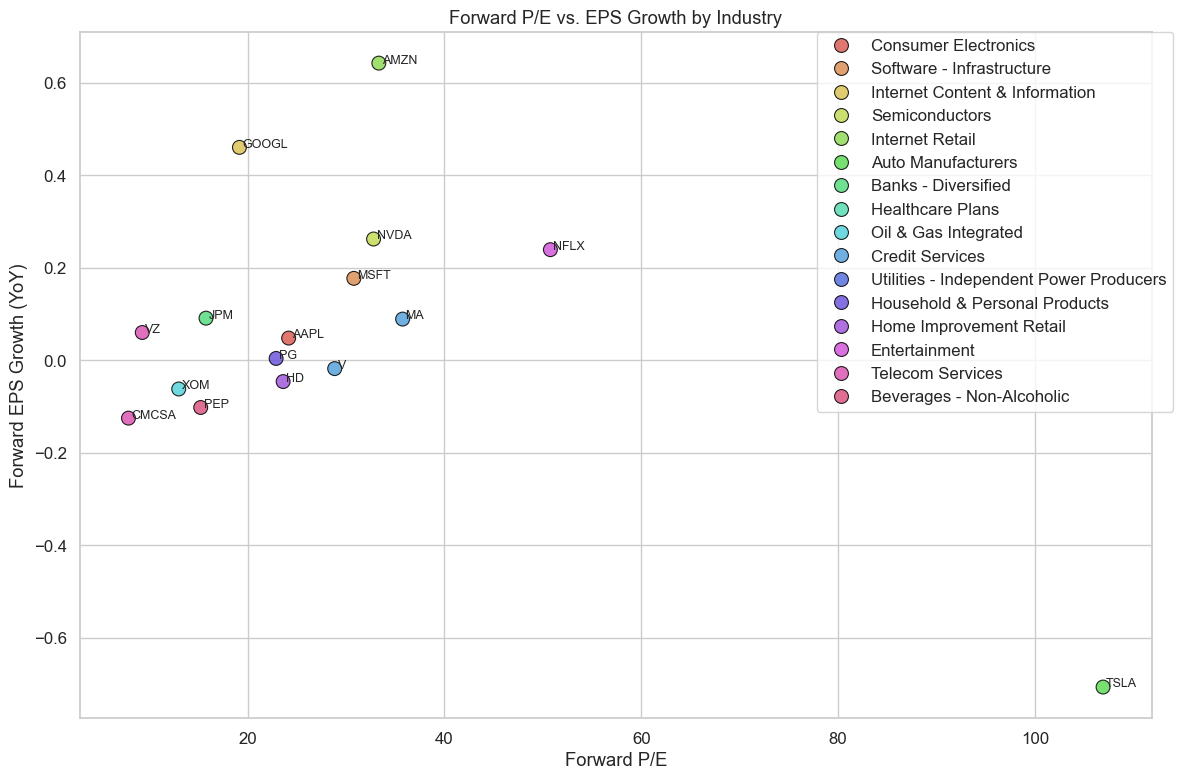

In [83]:
df
sns.set(style="whitegrid", font_scale=1.1)

# Create scatter plot
plt.figure(figsize=(12, 8))
palette = sns.color_palette("hls", df['industry'].nunique())

scatter = sns.scatterplot(
    data=df,
    x="forwardPEratio",
    y="growthRate",
    hue="industry",
    palette=palette,
    s=100,  # size of dots
    edgecolor="black",
    alpha=0.85
)

# Add ticker labels to each point
for _, row in df.iterrows():
    plt.text(row["forwardPEratio"] + 0.3, row["growthRate"], row["ticker"], fontsize=9)

plt.title("Forward P/E vs. EPS Growth by Industry")
plt.xlabel("Forward P/E")
plt.ylabel("Forward EPS Growth (YoY)")
plt.legend(loc='best', bbox_to_anchor=(1.02, 1), borderaxespad=0)
plt.tight_layout()
plt.show()

In [ ]:

inudstry_avg = df.groupby('industry')[['forwardPEratio', 'growthRate']].mean().reset_index()

In [54]:
import yfinance as yf
yf.Ticker("AAPL").info.get('forwardPE', None)

24.169674